In [1]:
from base import *
import sys,os
sys.path.append(os.path.abspath("../"))
from utils.functions import * 

In [10]:
metadata = pd.read_csv("../data/streamlit_sample_metadata.csv").set_index("sample_name")
data = pd.read_csv('../data/streamlit_sample_data.csv').set_index("sample_name")
# metadata = metadata[metadata.batch.isin([2,5,13,12,11])]
data = data.loc[metadata.index,:]
min_val = data.min().min() * .10
data = data[~data.index.str.contains("_BLANK_")]
metadata = metadata[~metadata.index.str.contains("_BLANK_")]

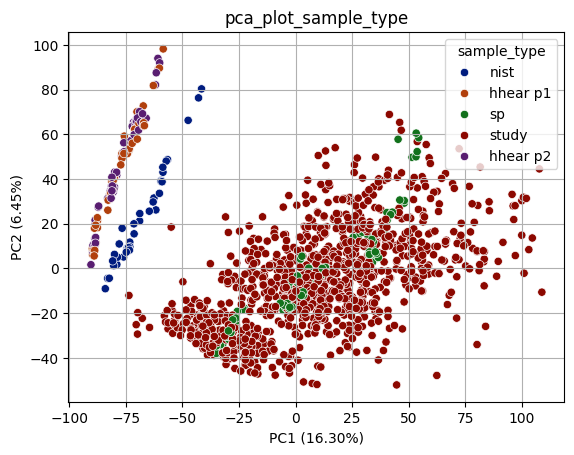

In [11]:
df = pca_plot(data.fillna(min_val),metadata,hues=['sample_type'])

,PC1,PC2,sample_type,batch
sample_name,,,,
AOU_NIST_001,-100.062053,4.814680,nist,1
AOU_HHEAR_P1_001,-118.400923,-6.667850,hhear p1,1
AOU_SP_001,8.371876,66.663444,sp,1
AOU_S_0001,10.900902,-1.684206,study,1
AOU_S_0002,21.291101,-19.667096,study,1
...,...,...,...,...
AOU_S_01039,6.680102,-12.824825,study,13
AOU_S_01040,2.738421,-0.980736,study,13
AOU_NIST_039,-100.886923,4.670150,nist,13


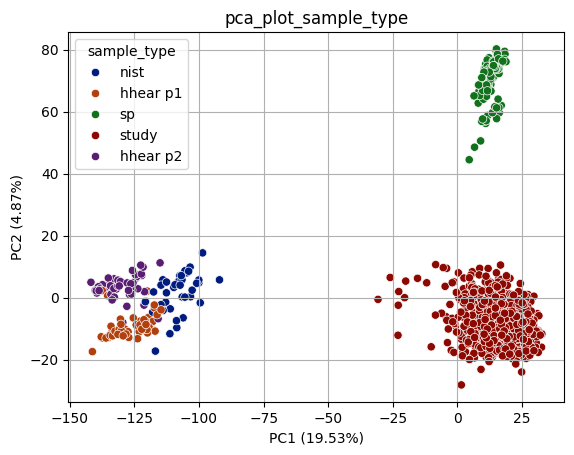

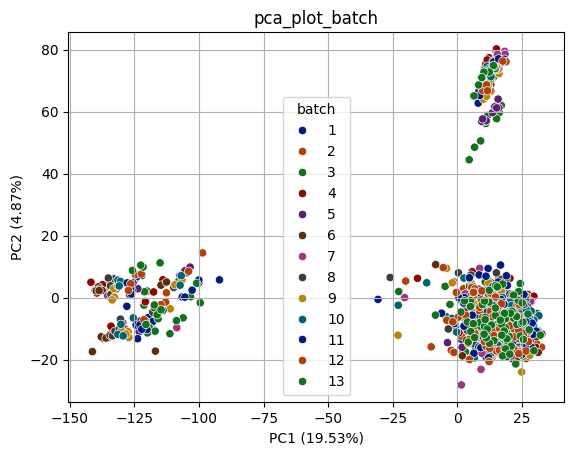

In [ ]:
pipeline = BatchCorrectionPipeline(
    method=Combat(qc_str='SP',blank_str="B"),
    preprocessing_config=Preprocessor(normalization_method='TIC',imputation_method='Global Minimum Value',log_transform=True)
)

results = pipeline.correct(data,metadata)
pca_plot(results,metadata,hues=['sample_type','batch'],plot_without_blanks=True)

def plot_signal_drift(data,n_features,n_batch,batch_idx,signal_idx,include_all_batches=False):
        n_signals = n_features
        n_batches = n_batch
        if signal_idx == "Random":
            signal_idx = np.random.randint(low=1,high=n_signals)
            signal_idx = data.columns[signal_idx]
        if batch_idx == "Random":
            batch_idx = np.random.randint(low=1,high=len(n_batches))
        signal_df = data.loc[:,signal_idx]
        signal_df = pd.DataFrame(signal_df,columns=[signal_df.name],index=signal_df.index)
        if not include_all_batches:
            signal_df = signal_df.groupby(metadata.batch).get_group(batch_idx)
        signal_df['batch'] = metadata.batch
        signal_df['injection_order'] = metadata.injection_order
        signal_df['sample_type'] = metadata.sample_type
        signal_df = signal_df.sort_values(by=["batch",'injection_order'])
        return signal_idx,batch_idx,signal_df



In [ ]:
pipeline = BatchCorrectionPipeline(
    method=Limma(covariates=['batch'],qc_str='SP',blank_str='B'),
    preprocessing_config=Preprocessor(normalization_method='TIC',imputation_method='Global Minimum Value',log_transform=True)
)

results = pipeline.correct(data,metadata)
pca_plot(results,metadata,hues=['sample_type','batch'],plot_without_blanks=True)

In [ ]:
pipeline = BatchCorrectionPipeline(
    method=MetNormalizer(qc_str='SP',blank_str='B'),
    preprocessing_config=Preprocessor(normalization_method='TIC',imputation_method='Global Minimum Value',log_transform=False)
)

results = pipeline.correct(data,metadata)

In [ ]:
pipeline = BatchCorrectionPipeline(
    method=SERRF(qc_str='SP',blank_str='B'),
    preprocessing_config=Preprocessor(normalization_method='TIC',imputation_method='Global Minimum Value',log_transform=False)
)

results = pipeline.correct(data,metadata)